In [1]:
import numpy as np
import pandas as pd
import risk_kit as rk
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

In [3]:
n_scenarios = 5000
rates, zc_prices = rk.cir(10, n_scenarios = n_scenarios, b = 0.03, r_0 = 0.03, sigma = 0.02)
price_eq = rk.gbm(n_years = 10, n_scenarios = n_scenarios, mu = 0.07, sigma = 0.15)

In [6]:
rets_eq = price_eq.pct_change().dropna()
rets_zc = zc_prices.pct_change().dropna()
rets_7030b = rk.bt_mix(rets_eq, rets_zc, allocator = rk.fixedmix_allocator, w1 = .7)
pd.concat([
    rk.terminal_stats(rets_zc, name = 'ZC', floor = .75),
    rk.terminal_stats(rets_eq, name = 'EQ', floor = .75),
    rk.terminal_stats(rets_7030b, name = '70/30', floor = .75)
], axis = 1).round(2)

,ZC,EQ,70/30
mean,1.34,1.98,1.76
std,0.00,0.99,0.60
p_breach,NaN,0.04,0.01
e_short,NaN,0.12,0.06
p_reach,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN


In [8]:
rets_floor75 = rk.bt_mix(rets_eq, rets_zc, allocator = rk.floor_allocator, floor = .75, zc_prices = zc_prices[1:])

In [11]:
pd.concat([
    rk.terminal_stats(rets_zc, name = 'ZC', floor = .75),
    rk.terminal_stats(rets_eq, name = 'EQ', floor = .75),
    rk.terminal_stats(rets_7030b, name = '70/30', floor = .75),
    rk.terminal_stats(rets_floor75, name = 'Floor75', floor = .75)
], axis = 1).round(2)

,ZC,EQ,70/30,Floor75
mean,1.34,1.98,1.76,1.96
std,0.00,0.99,0.60,1.00
p_breach,NaN,0.04,0.01,NaN
e_short,NaN,0.12,0.06,NaN
p_reach,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN


In [12]:
rets_floor75m1 = rk.bt_mix(rets_eq, rets_zc, allocator = rk.floor_allocator, floor = .75, zc_prices = zc_prices[1:], m = 1)
rets_floor75m5 = rk.bt_mix(rets_eq, rets_zc, allocator = rk.floor_allocator, floor = .75, zc_prices = zc_prices[1:], m = 5)

In [13]:
pd.concat([
    rk.terminal_stats(rets_zc, name = 'ZC', floor = .75),
    rk.terminal_stats(rets_eq, name = 'EQ', floor = .75),
    rk.terminal_stats(rets_7030b, name = '70/30', floor = .75),
    rk.terminal_stats(rets_floor75, name = 'Floor75', floor = .75),
    rk.terminal_stats(rets_floor75m1, name = 'Floor75m1', floor = .75),
    rk.terminal_stats(rets_floor75m5, name = 'Floor75m5', floor = .75)
], axis = 1).round(2)

,ZC,EQ,70/30,Floor75,Floor75m1,Floor75m5
mean,1.34,1.98,1.76,1.96,1.63,1.96
std,0.00,0.99,0.60,1.00,0.44,1.00
p_breach,NaN,0.04,0.01,NaN,NaN,NaN
e_short,NaN,0.12,0.06,NaN,NaN,NaN
p_reach,NaN,NaN,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN,NaN,NaN


## Risk Budgeting with Drawdown Constraints

In [14]:
cashrate = .02
monthly_cashreturn = (1 + cashrate)**(1/12) - 1
rets_cash = pd.DataFrame(data = monthly_cashreturn, index = rets_eq.index, columns = rets_eq.columns)
rets_maxdd25 = rk.bt_mix(rets_eq, rets_cash, allocator = rk.drawdown_allocator, maxdd = .25)
tv_maxdd25 = rk.terminal_values(rets_maxdd25)

In [17]:
rk.summary_stats(rets_maxdd25)['Max Drawdown'].head()

0   -0.193643
1   -0.187092
2   -0.170171
3   -0.139171
4   -0.149471
Name: Max Drawdown, dtype: float64

In [18]:
rk.summary_stats(rets_maxdd25)['Max Drawdown'].min()

-0.2345708929113346

C:\Users\Yifei\AppData\Local\Temp\ipykernel_22112\2237739740.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tv_eq, color="red", label="100% Equities", bins=100)
C:\Users\Yifei\AppData\Local\Temp\ipykernel_22112\2237739740.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tv_7030b, color="

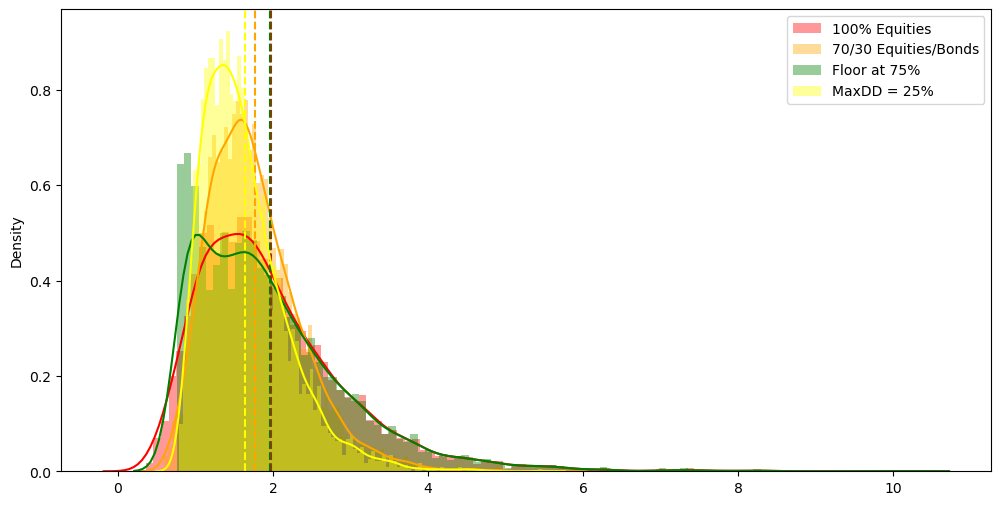

In [19]:
tv_eq = rk.terminal_values(rets_eq)
tv_zc = rk.terminal_values(rets_zc)
tv_7030b = rk.terminal_values(rets_7030b)
tv_floor75 = rk.terminal_values(rets_floor75)
tv_maxdd25 = rk.terminal_values(rets_maxdd25)
plt.figure(figsize=(12, 6))
sns.distplot(tv_eq, color="red", label="100% Equities", bins=100)
plt.axvline(tv_eq.mean(), ls="--", color="red")
sns.distplot(tv_7030b, color="orange", label="70/30 Equities/Bonds", bins=100)
plt.axvline(tv_7030b.mean(), ls="--", color="orange")
sns.distplot(tv_floor75, color="green", label="Floor at 75%", bins=100)
plt.axvline(tv_floor75.mean(), ls="--", color="green")
sns.distplot(tv_maxdd25, color="yellow", label="MaxDD = 25%", bins=100)
plt.axvline(tv_maxdd25.mean(), ls="--", color="yellow")

plt.legend();

## Drawdown constraint with Historical Data

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('data/ind30_m_vw_rets.csv',


<Axes: >

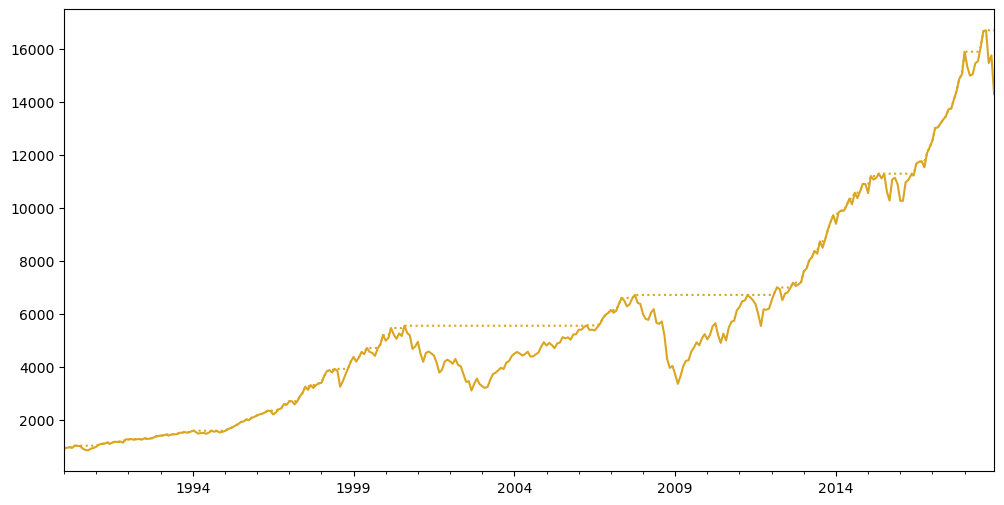

In [22]:
rets_tmi =  rk.get_total_market_index_returns()["1990":]
dd_tmi = rk.drawdown(rets_tmi)
ax = dd_tmi["Wealth"].plot(figsize=(12,6), ls="-", color="goldenrod")
dd_tmi["Peaks"].plot(ax=ax, ls=":", color="goldenrod")

<Axes: >

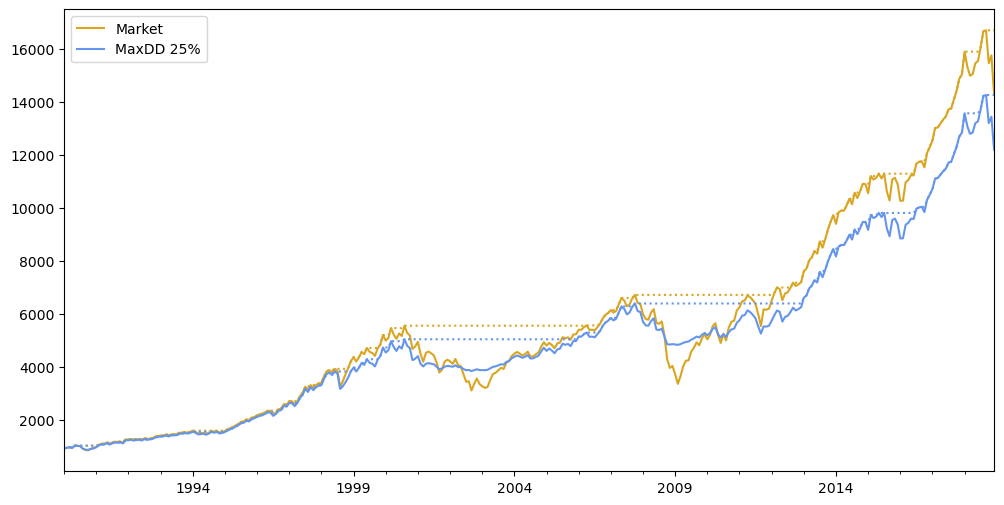

In [23]:
cashrate = 0.03
monthly_cashreturn = (1+cashrate)**(1/12) - 1
rets_cash = pd.DataFrame(data= monthly_cashreturn, index=rets_tmi.index, columns=[0]) # 1 column dataframe
rets_maxdd25 = rk.bt_mix(pd.DataFrame(rets_tmi), rets_cash, allocator=rk.drawdown_allocator, maxdd=.25, m=5)
dd_25 = rk.drawdown(rets_maxdd25[0])

ax = dd_tmi["Wealth"].plot(figsize=(12,6), ls="-", color="goldenrod", label="Market", legend=True)
dd_tmi["Peaks"].plot(ax=ax, ls=":", color="goldenrod")
dd_25["Wealth"].plot(ax=ax, label="MaxDD 25%", color="cornflowerblue", legend=True)
dd_25["Peaks"].plot(ax=ax, color="cornflowerblue", ls=":")

In [24]:
rk.summary_stats(pd.concat([rets_tmi.rename("Market"), rets_maxdd25[0].rename("MaxDD")], axis=1))

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
Market,0.096058,0.145419,-0.668827,4.247282,0.066949,0.094633,0.441951,-0.499943
MaxDD,0.090062,0.112755,-0.630463,5.015334,0.049978,0.071074,0.518327,-0.244212
